In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import joblib

train_df = pd.read_parquet("../artifacts/final_train.parquet")
val_df = pd.read_parquet("../artifacts/final_val.parquet")
test_df = pd.read_parquet("../artifacts/final_test.parquet")
X_train = train_df.drop(columns=["is_late"])
y_train = train_df["is_late"]
X_val = val_df.drop(columns=["is_late"])
y_val = val_df["is_late"]
X_test = test_df.drop(columns=["is_late"])
y_test = test_df["is_late"]

print(" Data loaded successfully for modeling!")
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

✅ Data loaded successfully for modeling!
X_train shape: (69608, 1261)
X_val shape: (14916, 1261)
X_test shape: (14917, 1261)


In [10]:
baseline_model = LogisticRegression(max_iter=2000, random_state=42)
baseline_model.fit(X_train, y_train)
y_val_pred_proba = baseline_model.predict_proba(X_val)[:, 1]
baseline_auc = roc_auc_score(y_val, y_val_pred_proba)
print(f"🎯 Baseline Validation ROC-AUC Score: {baseline_auc:.4f}")

🎯 Baseline Validation ROC-AUC Score: 0.7478


c:\Users\shima\OneDrive\Desktop\task 2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]
best_auc = 0
best_c = None
best_model = None

for c in C_values:
    print(f"Training LogisticRegression with C={c}...")
    model = LogisticRegression(C=c, max_iter=3000, random_state=42)
    model.fit(X_train, y_train)
    
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_pred_proba)
    
    print(f"-> Validation ROC-AUC for C={c}: {auc:.4f}")
    
    if auc > best_auc:
        best_auc = auc
        best_c = c
        best_model = model

print("\n" + "="*40)
print(f" Best C parameter: {best_c}")
print(f" Best Validation ROC-AUC Score: {best_auc:.4f}")

Training LogisticRegression with C=0.001...
-> Validation ROC-AUC for C=0.001: 0.7309
Training LogisticRegression with C=0.01...


c:\Users\shima\OneDrive\Desktop\task 2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


-> Validation ROC-AUC for C=0.01: 0.7483
Training LogisticRegression with C=0.1...


c:\Users\shima\OneDrive\Desktop\task 2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


-> Validation ROC-AUC for C=0.1: 0.7536
Training LogisticRegression with C=1.0...


c:\Users\shima\OneDrive\Desktop\task 2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


-> Validation ROC-AUC for C=1.0: 0.7495
Training LogisticRegression with C=10.0...
-> Validation ROC-AUC for C=10.0: 0.7557

🎯 Best C parameter: 10.0
🎯 Best Validation ROC-AUC Score: 0.7557


c:\Users\shima\OneDrive\Desktop\task 2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f" Final Test Set ROC-AUC Score: {test_auc:.4f}")
import os
import joblib
os.makedirs("../artifacts", exist_ok=True)
joblib.dump(best_model, "../artifacts/best_logistic_regression_model.pkl")

results_summary = {
    "model_name": "Logistic Regression",
    "best_hyperparameters": {"C": best_c},
    "validation_roc_auc": best_auc,
    "test_roc_auc": test_auc
}
joblib.dump(results_summary, "../artifacts/results_summary.pkl")
print("Model and results summary saved successfully in artifacts!")

 Final Test Set ROC-AUC Score: 0.6548
Model and results summary saved successfully in artifacts!


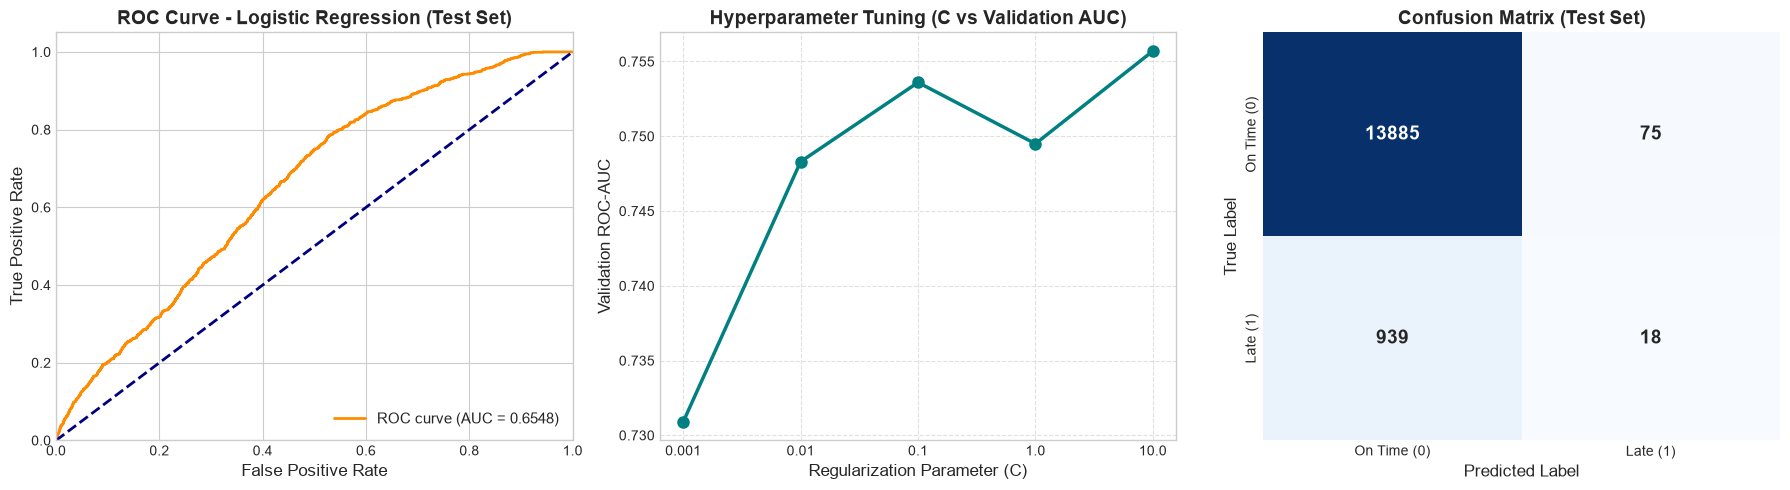

 Evaluation charts generated, displayed, and saved successfully as an artifact!


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

# إعداد تنسيق الرسومات
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. منحنى الـ ROC Curve ---
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)

axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve - Logistic Regression (Test Set)', fontsize=14, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=11)

# --- 2. مقارنة أداء قيم C أثناء الـ Tuning ---
c_vals_str = ['0.001', '0.01', '0.1', '1.0', '10.0']
auc_scores = [0.7309, 0.7483, 0.7536, 0.7495, 0.7557]

axes[1].plot(c_vals_str, auc_scores, marker='o', color='teal', lw=2.5, markersize=8)
axes[1].set_xlabel('Regularization Parameter (C)', fontsize=12)
axes[1].set_ylabel('Validation ROC-AUC', fontsize=12)
axes[1].set_title('Hyperparameter Tuning (C vs Validation AUC)', fontsize=14, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

# --- 3. مصفوفة الارتباك (Confusion Matrix) ---
# استخدام عتبة افتراضية 0.5 أو يمكنك تعديلها
y_test_pred = (y_test_pred_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[2], 
            annot_kws={"size": 14, "weight": "bold"})
axes[2].set_xlabel('Predicted Label', fontsize=12)
axes[2].set_ylabel('True Label', fontsize=12)
axes[2].set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
axes[2].xaxis.set_ticklabels(['On Time (0)', 'Late (1)'])
axes[2].yaxis.set_ticklabels(['On Time (0)', 'Late (1)'])

plt.tight_layout()

# حفظ الرسم البياني كـ Artifact
plt.savefig("../artifacts/evaluation_charts.png", dpi=300)
plt.show()

print(" Evaluation charts generated, displayed, and saved successfully as an artifact!")